# Lesson Coverage

Use the following checklist.

## Behind .fit()

- [x] Hypothesis Function
- [x] X / y / beta
- [x] LinearRegression.fit()
- [x] intercept_
- [x] coef_
- [x] Prediction from learned beta
- [x] Residual
- [x] OLS / Squared Loss
- [x] Loss minimization concept

## Gradient Descent

- [x] Manual Gradient Descent
- [x] Partial Derivative
- [x] Gradient Vector
- [x] Parameter Update Rule
- [x] Learning Rate
- [x] Epoch
- [x] Minimum Step Size
- [x] Maximum Epochs
- [x] Convergence
- [x] Multi-parameter Gradient Descent
- [x] Scaling effect
- [x] Loss Landscape / Energy Landscape
- [x] Contour Plot

## OLS Geometry

- [x] Column Space concept
- [x] Orthogonal Projection concept
- [x] X^T residual approximately zero

## Other Solvers

- [x] Batch Gradient Descent
- [x] Mini-Batch Gradient Descent
- [x] SGD
- [x] SGDRegressor
- [ ] SGDClassifier
- [x] LinearRegression vs SGDRegressor
- [x] Solver scaling benchmark
- [ ] Momentum concept
- [ ] AdaGrad concept
- [ ] RMSProp concept
- [ ] Adam concept
- [ ] Newton / Second-Order concept
- [ ] L-BFGS concept

## Regression Losses

- [ ] L1 / MAE
- [ ] L2 / MSE
- [ ] Huber Loss
- [ ] SGDRegressor squared_error
- [ ] SGDRegressor huber

## Classification Losses

- [ ] Binary classification target
- [ ] Logistic probability concept
- [ ] Likelihood / Log-Likelihood concept
- [ ] Log Loss / Cross-Entropy
- [ ] SGDClassifier log_loss
- [ ] Hinge Loss
- [ ] SGDClassifier hinge
- [ ] LogisticRegression newton-cg
- [ ] LogisticRegression lbfgs

## Final Concepts

- [ ] Loss vs Performance Metric
- [ ] Parameter vs Hyperparameter
- [ ] Hypothesis vs Loss vs Solver
- [ ] Final training chain

# 1. Load California Housing Dataset

We load the California Housing dataset directly from `sklearn.datasets.fetch_california_housing(as_frame=True)`.
The goal of this project is to inspect the training and optimization process behind machine learning estimators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load dataset as pandas dataframe
housing = fetch_california_housing(as_frame=True)
data = housing.frame

print("Loaded California Housing dataset:")
print(f"data.shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Loaded California Housing dataset:
data.shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 2. Minimal Data Audit

This lesson is focused on **Training and Optimization**, not data preprocessing or cleaning.
We perform a minimal structural audit to confirm data integrity:
- Target column `MedHouseVal` is expressed in units of **$100,000**.
- The dataset is strictly numerical with no missing values and no duplicate rows.
- No feature scaling, cleaning, or outlier removal is required for the baseline one-feature demonstration.

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal duplicate rows: {data.duplicated().sum()}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total duplicate rows: 0


In [4]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# 3. Define Feature Matrix X and Target Vector y

For this initial lesson step, we isolate a single input feature:
- **Feature $X$**: `MedInc` (Median income in block group)
- **Target $y$**: `MedHouseVal` (Median house value)

### Notation:
- $X$ is the design / feature matrix.
- $y$ is the ground-truth observation target.
- $\beta$ represents the parameters that the estimator will learn during `.fit()`.

In [5]:
X = data[["MedInc"]]
y = data["MedHouseVal"]

print(f"X shape: {X.shape} (Feature: {list(X.columns)})")
print(f"y shape: {y.shape} (Target: {y.name})")

X shape: (20640, 1) (Feature: ['MedInc'])
y shape: (20640,) (Target: MedHouseVal)


# 4. Train / Test Split

We partition the data into an 80% training set and a 20% test set using `random_state=42`.
No scaling or stratification is performed.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (16512, 1), y_train shape: (16512,)
X_test shape:  (4128, 1), y_test shape:  (4128,)


# 5. Linear Regression Baseline & Learned Parameters

We fit `LinearRegression()` on `(X_train, y_train)` and inspect the learned parameters:
- **Intercept**: `model.intercept_` (corresponds to $\beta_0$)
- **Slope / Coefficient**: `model.coef_[0]` (corresponds to $\beta_1$)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

beta_0 = model.intercept_
beta_1 = model.coef_[0]

print(f"Learned beta_0 (intercept_): {beta_0:.6f}")
print(f"Learned beta_1 (coef_[0]):   {beta_1:.6f}")

Learned beta_0 (intercept_): 0.444597
Learned beta_1 (coef_[0]):   0.419338


# 6. The Hypothesis Function

In machine learning regression, the hypothesis function maps inputs $X$ and parameters $\beta$ to a prediction $\hat{y}$:
$$y = h(X, \beta) + \varepsilon$$
$$\hat{y} = h(X, \beta)$$

For a single-feature linear model:
$$h(X, \beta) = \beta_0 + \beta_1 \cdot \text{MedInc}$$

We define this mathematical function explicitly and verify that manual evaluation matches `model.predict()`.

In [8]:
def h(x, beta_0, beta_1):
    """Manual hypothesis function: h(x, beta) = beta_0 + beta_1 * x"""
    return beta_0 + beta_1 * x

# Check manual predictions against scikit-learn on the first 5 test samples
sample_x = X_test.iloc[:5]["MedInc"].values
manual_sample_preds = h(sample_x, beta_0, beta_1)
sklearn_sample_preds = model.predict(X_test.iloc[:5])

for i, (val_x, m_pred, sk_pred) in enumerate(zip(sample_x, manual_sample_preds, sklearn_sample_preds)):
    print(f"Sample {i}: MedInc={val_x:.4f} -> Manual h(x)={m_pred:.6f} | model.predict={sk_pred:.6f}")

assert np.allclose(manual_sample_preds, sklearn_sample_preds), "Manual predictions do not match model.predict!"
print("\nVerification confirmed: Manual hypothesis evaluations match model.predict() exactly.")

Sample 0: MedInc=1.6812 -> Manual h(x)=1.149589 | model.predict=1.149589
Sample 1: MedInc=2.5313 -> Manual h(x)=1.506069 | model.predict=1.506069
Sample 2: MedInc=3.4801 -> Manual h(x)=1.903937 | model.predict=1.903937
Sample 3: MedInc=5.7376 -> Manual h(x)=2.850594 | model.predict=2.850594
Sample 4: MedInc=3.7250 -> Manual h(x)=2.006633 | model.predict=2.006633

Verification confirmed: Manual hypothesis evaluations match model.predict() exactly.


# 7. Model Predictions

We generate predictions across the full test set and construct a comparison table.

In [9]:
y_pred = model.predict(X_test)

prediction_check = pd.DataFrame({
    "MedInc": X_test["MedInc"],
    "actual": y_test,
    "predicted": y_pred
})

prediction_check.head(10)

,MedInc,actual,predicted
20046,1.6812,0.47700,1.149589
3024,2.5313,0.45800,1.506069
15663,3.4801,5.00001,1.903937
20484,5.7376,2.18600,2.850594
9814,3.7250,2.78000,2.006633
13311,4.7147,1.58700,2.421652
7113,5.0839,1.98200,2.576472
7668,3.6908,1.57500,1.992292
18246,4.8036,3.40000,2.458932
5723,8.1132,4.46600,3.846774


# 8. Residuals

The residual is the difference between actual ground-truth target and model prediction:
$$\text{Residual}_i = y_i - \hat{y}_i$$

In [10]:
residuals = y_test - y_pred
prediction_check["residual"] = residuals

print("First 10 test predictions with residuals:")
prediction_check.head(10)

First 10 test predictions with residuals:


,MedInc,actual,predicted,residual
20046,1.6812,0.47700,1.149589,-0.672589
3024,2.5313,0.45800,1.506069,-1.048069
15663,3.4801,5.00001,1.903937,3.096073
20484,5.7376,2.18600,2.850594,-0.664594
9814,3.7250,2.78000,2.006633,0.773367
13311,4.7147,1.58700,2.421652,-0.834652
7113,5.0839,1.98200,2.576472,-0.594472
7668,3.6908,1.57500,1.992292,-0.417292
18246,4.8036,3.40000,2.458932,0.941068
5723,8.1132,4.46600,3.846774,0.619226


# 9. OLS / Squared Loss

Ordinary Least Squares (OLS) chooses parameters $\beta$ that minimize the sum of squared errors:
$$\text{SSR} = \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
$$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$

We compute both SSR and MSE on the test set.

In [11]:
ssr = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)

print(f"Sum of Squared Residuals (SSR): {ssr:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")

Sum of Squared Residuals (SSR): 2927.2299
Mean Squared Error (MSE):       0.7091


# 10. Manual Loss Check Around Learned $\beta$

To demonstrate the concept of **loss minimization** before introducing Gradient Descent:
1. We keep $\beta_1$ fixed at the learned value.
2. We evaluate alternative candidate $\beta_0$ values in a neighborhood around the learned intercept ($\beta_0 \pm \delta$).
3. We compute the training Sum of Squared Residuals (SSR) for each candidate.

Because `.fit()` minimizes the training squared-error objective, the learned $\beta_0$ must produce a lower loss than any nearby alternative.

In [12]:
fixed_beta_1 = beta_1
deltas = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

X_tr_vals = X_train["MedInc"].values
y_tr_vals = y_train.values

loss_comparison = []
for d in deltas:
    cand_b0 = beta_0 + d
    cand_preds = h(X_tr_vals, cand_b0, fixed_beta_1)
    cand_ssr = np.sum((y_tr_vals - cand_preds) ** 2)
    cand_mse = np.mean((y_tr_vals - cand_preds) ** 2)
    loss_comparison.append({
        "delta": d,
        "beta_0": cand_b0,
        "is_learned": (d == 0.0),
        "SSR (Train)": cand_ssr,
        "MSE (Train)": cand_mse
    })

loss_table = pd.DataFrame(loss_comparison)
loss_table

,delta,beta_0,is_learned,SSR (Train),MSE (Train)
0,-0.20,0.244597,False,12204.757567,0.739145
1,-0.10,0.344597,False,11709.397567,0.709145
2,-0.05,0.394597,False,11585.557567,0.701645
3,0.00,0.444597,True,11544.277567,0.699145
4,0.05,0.494597,False,11585.557567,0.701645
5,0.10,0.544597,False,11709.397567,0.709145
6,0.20,0.644597,False,12204.757567,0.739145


# 11. Visualizing the Fitted Hypothesis Line

We plot a sample of the training observations alongside the fitted hypothesis line:
$$\hat{y} = \beta_0 + \beta_1 \cdot \text{MedInc}$$

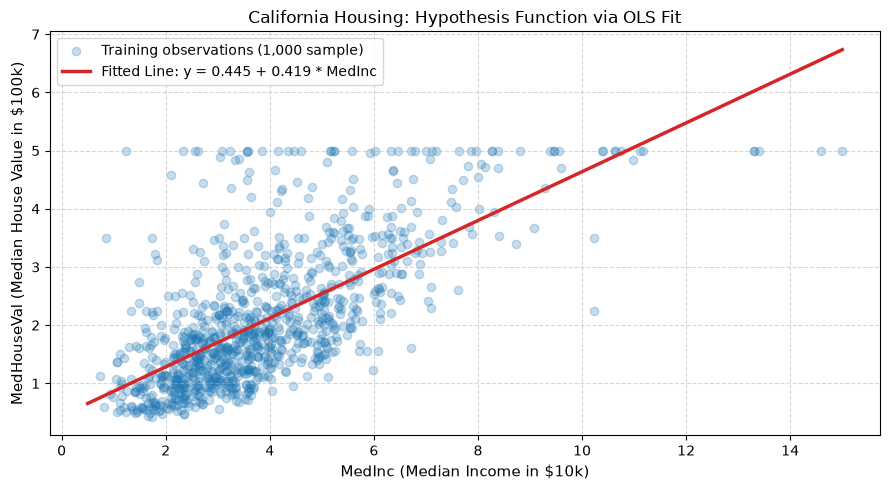

In [13]:
plt.figure(figsize=(9, 5))

# Subsample points for clear visualization
sample_idx = np.random.RandomState(42).choice(len(X_train), size=1000, replace=False)
plt.scatter(
    X_train.iloc[sample_idx]["MedInc"],
    y_train.iloc[sample_idx],
    alpha=0.25,
    color="#1f77b4",
    label="Training observations (1,000 sample)"
)

# Plot fitted regression line
x_line = np.linspace(X_train["MedInc"].min(), X_train["MedInc"].max(), 200)
y_line = h(x_line, beta_0, beta_1)
plt.plot(x_line, y_line, color="#d62728", linewidth=2.5, label=f"Fitted Line: y = {beta_0:.3f} + {beta_1:.3f} * MedInc")

plt.title("California Housing: Hypothesis Function via OLS Fit", fontsize=12)
plt.xlabel("MedInc (Median Income in $10k)", fontsize=11)
plt.ylabel("MedHouseVal (Median House Value in $100k)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 12. Explaining What `.fit()` Did

### The Training Chain:
```
Choose Hypothesis
       ↓
   .fit(X, y)
       ↓
Solver minimizes Loss
       ↓
   Learn beta
       ↓
 Trained Model
```

- **Before `.fit()`**:
  The `LinearRegression` model is initialized with a hypothesis architecture:
  $$h(X, \beta) = \beta_0 + \beta_1 X$$
  However, it has not seen the California Housing data and parameters $\beta$ are undetermined.

- **During `.fit()`**:
  The solver identifies the optimal parameters $\beta^*$ that minimize the squared-error loss:
  $$\min_{\beta_0, \beta_1} \sum_{i=1}^N \left(y_i - (\beta_0 + \beta_1 x_i)\right)^2$$
  *Note*: scikit-learn solves this least-squares problem using numerical linear algebra (specifically Singular Value Decomposition / LAPACK `gelsd`), not brute-force iteration.

- **After `.fit()`**:
  The learned parameters are stored in:
  - `model.intercept_` ($\beta_0 = 0.444597$)
  - `model.coef_` ($\beta_1 = 0.419338$)
  Predictions can now be computed deterministically for any input value.

# 13. Parameter vs Hyperparameter Preview

- **Parameters (Learned)**:
  Values computed during `.fit()` directly from the training data:
  $$\beta_0, \beta_1$$
- **Hyperparameters (Configured)**:
  Settings chosen by the practitioner *before* calling `.fit()`, such as:
  `fit_intercept=True`, `copy_X=True`

*(A comprehensive study of hyperparameters versus parameters will be conducted in subsequent lessons.)*

# 14. Step 1 Programmatic Verification

We run automated assertions confirming all requirements of Step 1 are strictly fulfilled.

In [14]:
# Programmatic verifications
assert data.shape == (20640, 9), f"Unexpected data shape: {data.shape}"
assert len(data.columns) == 9, "Unexpected number of columns"
assert "MedHouseVal" in data.columns, "MedHouseVal target missing"
assert data.isnull().sum().sum() == 0, "Found unexpected missing values"
assert data.duplicated().sum() == 0, "Found unexpected duplicate rows"

assert X.columns.tolist() == ["MedInc"], f"X should contain only MedInc, found {X.columns.tolist()}"
assert y.name == "MedHouseVal", "y should be MedHouseVal"
assert len(X_train) == 16512 and len(X_test) == 4128, "Incorrect split sizes"
assert isinstance(model, LinearRegression), "Model is not LinearRegression"
assert np.isclose(beta_0, model.intercept_), "beta_0 mismatch"
assert np.isclose(beta_1, model.coef_[0]), "beta_1 mismatch"

# Hypothesis predictions check
test_preds = model.predict(X_test)
manual_test_preds = h(X_test["MedInc"].values, beta_0, beta_1)
assert np.allclose(test_preds, manual_test_preds), "Predictions do not match"

# Residual check
calc_residuals = y_test - test_preds
assert np.allclose(calc_residuals, residuals), "Residual mismatch"
assert ssr >= 0, "SSR must be non-negative"
assert mse >= 0, "MSE must be non-negative"

# Check that loss at learned beta_0 is strictly smaller than at candidate offsets
learned_train_ssr = np.sum((y_train.values - h(X_train["MedInc"].values, beta_0, beta_1)) ** 2)
for d in [-0.20, -0.10, -0.05, 0.05, 0.10, 0.20]:
    cand_ssr = np.sum((y_train.values - h(X_train["MedInc"].values, beta_0 + d, beta_1)) ** 2)
    assert cand_ssr > learned_train_ssr, f"Learned beta_0 is not optimal compared to delta {d}"

# Verify out-of-scope items: no scaling applied yet (raw data has mean ~3.88 and std ~1.90, not standard normal)
assert 3.5 < X_train["MedInc"].mean() < 4.2, f"Data was unexpectedly scaled! Mean: {X_train['MedInc'].mean()}"
assert 1.5 < X_train["MedInc"].std() < 2.5, f"Data was unexpectedly scaled! Std: {X_train['MedInc'].std()}"

print("✓ All Step 1 programmatic verifications passed successfully!")

✓ All Step 1 programmatic verifications passed successfully!


# 15. The Gradient Descent Idea

In machine learning, training an estimator corresponds to solving an optimization problem:
$$\text{.fit()} \longrightarrow \min_\beta \text{Loss}(\beta) \longrightarrow \text{optimal } \beta^*$$

When an exact analytical formula is unavailable or computationally expensive, we use an iterative optimization algorithm: **Gradient Descent**.

The fundamental parameter update rule is:
$$\beta_{\text{new}} = \beta_{\text{old}} - \eta \cdot \text{derivative}$$

- **Learning Rate ($\eta$)**: A positive hyperparameter that controls how large a step to take along the descent direction.
- **Derivative / Gradient**: The rate of change of the loss function with respect to parameter $\beta$. It points in the direction of steepest *ascent*; hence, subtracting it moves the parameter in the direction of steepest *descent* toward the minimum.

# 16. First Experiment: Optimizing Only $\beta_0$ (Intercept)

Following the lesson progression, we isolate the optimization process by keeping the slope parameter fixed at its learned value:
$$\text{fixed\_}\beta_1 = \beta_1 = 0.419338$$

We optimize only the intercept parameter $\beta_0$, starting from an uninformative guess:
$$\beta_0^{(0)} = 0.0$$

The hypothesis function with fixed slope is:
$$h_{\text{intercept}}(x, \beta_0) = \beta_0 + \text{fixed\_}\beta_1 \cdot x$$

### Mean Squared Error Loss and Partial Derivative
Because our dataset contains 16,512 training observations, we optimize the **Mean Squared Error (MSE)** rather than raw sum-of-squares. This keeps the gradient magnitude normalized and independent of dataset sample size:
$$\text{Loss}(\beta_0) = \frac{1}{N} \sum_{i=1}^N \left(y_i - (\beta_0 + \text{fixed\_}\beta_1 \cdot x_i)\right)^2$$

Taking the partial derivative with respect to $\beta_0$:
$$\frac{\partial \text{Loss}}{\partial \beta_0} = \frac{1}{N} \sum_{i=1}^N -2 \left(y_i - (\beta_0 + \text{fixed\_}\beta_1 \cdot x_i)\right) = \text{mean}\left(-2 \cdot (y - \hat{y})\right)$$

In [15]:
fixed_beta_1 = beta_1
X_tr_vals = X_train["MedInc"].values
y_tr_vals = y_train.values

def h_intercept_only(x, b0):
    """Hypothesis with slope fixed at learned beta_1."""
    return b0 + fixed_beta_1 * x

def compute_loss_b0(b0):
    """Mean squared error loss w.r.t b0."""
    preds = h_intercept_only(X_tr_vals, b0)
    return float(np.mean((y_tr_vals - preds) ** 2))

def compute_derivative_b0(b0):
    """Partial derivative dLoss/db0."""
    preds = h_intercept_only(X_tr_vals, b0)
    return float(np.mean(-2 * (y_tr_vals - preds)))

print("Definitions complete.")

Definitions complete.


# 17. Manual Calculation of Epoch 0 and Epoch 1

Before running an automated loop, we calculate the first two epochs explicitly step by step.
Several learning rates were tested empirically. $\eta = 0.10$ produced stable convergence for the intercept-only experiment.

In [16]:
eta_b0 = 0.1

# --- EPOCH 0 ---
b0_epoch0 = 0.0
loss_epoch0 = compute_loss_b0(b0_epoch0)
deriv_epoch0 = compute_derivative_b0(b0_epoch0)
step_size_epoch0 = eta_b0 * deriv_epoch0

# Parameter update rule: beta_new = beta_old - eta * derivative
b0_epoch1 = b0_epoch0 - step_size_epoch0

print("=== EPOCH 0 ===")
print(f"Starting beta_0:   {b0_epoch0:.6f}")
print(f"Loss (MSE):        {loss_epoch0:.6f}")
print(f"Derivative:        {deriv_epoch0:.6f}")
print(f"Step (eta * dL):   {step_size_epoch0:.6f}")
print(f"Updated beta_0:    {b0_epoch1:.6f}")

# --- EPOCH 1 ---
loss_epoch1 = compute_loss_b0(b0_epoch1)
deriv_epoch1 = compute_derivative_b0(b0_epoch1)
step_size_epoch1 = eta_b0 * deriv_epoch1
b0_epoch2 = b0_epoch1 - step_size_epoch1

print("\n=== EPOCH 1 ===")
print(f"Starting beta_0:   {b0_epoch1:.6f}")
print(f"Loss (MSE):        {loss_epoch1:.6f}")
print(f"Derivative:        {deriv_epoch1:.6f}")
print(f"Step (eta * dL):   {step_size_epoch1:.6f}")
print(f"Updated beta_0:    {b0_epoch2:.6f}")

=== EPOCH 0 ===
Starting beta_0:   0.000000
Loss (MSE):        0.896811
Derivative:        -0.889195
Step (eta * dL):   -0.088919
Updated beta_0:    0.088919

=== EPOCH 1 ===
Starting beta_0:   0.088919
Loss (MSE):        0.825651
Derivative:        -0.711356
Step (eta * dL):   -0.071136
Updated beta_0:    0.160055


# 18. Iterative Optimization Loop for $\beta_0$

We now run the optimization loop until either:
1. **Minimum step size** is reached: $|\text{step\_size}| < 10^{-6}$ (gradient is practically zero, indicating convergence).
2. **Maximum epochs** is reached: `max_epochs = 1000` (safety termination).

In [17]:
b0_current = 0.0
max_epochs = 1000
min_step_size = 1e-6

history_b0 = []
stopping_reason_b0 = ""

for epoch in range(max_epochs):
    loss_val = compute_loss_b0(b0_current)
    deriv_val = compute_derivative_b0(b0_current)
    step_val = eta_b0 * deriv_val
    
    history_b0.append({
        "epoch": epoch,
        "beta_0": b0_current,
        "loss": loss_val,
        "derivative": deriv_val,
        "step_size": step_val
    })
    
    if abs(step_val) < min_step_size:
        stopping_reason_b0 = f"Minimum step size reached (|step| = {abs(step_val):.2e} < {min_step_size})"
        break
        
    b0_current -= step_val
else:
    stopping_reason_b0 = "Maximum epochs reached"

b0_df = pd.DataFrame(history_b0)

print(f"Convergence Reason: {stopping_reason_b0}")
print(f"Total Epochs Run:   {len(b0_df)}")
print(f"Final beta_0:       {b0_current:.6f}")
print(f"Final Loss (MSE):   {history_b0[-1]['loss']:.6f}")
b0_df.head(6)

Convergence Reason: Minimum step size reached (|step| = 8.12e-07 < 1e-06)
Total Epochs Run:   53
Final beta_0:       0.444593
Final Loss (MSE):   0.699145


,epoch,beta_0,loss,derivative,step_size
0,0,0.000000,0.896811,-0.889195,-0.088919
1,1,0.088919,0.825651,-0.711356,-0.071136
2,2,0.160055,0.780109,-0.569085,-0.056908
3,3,0.216963,0.750962,-0.455268,-0.045527
4,4,0.262490,0.732308,-0.364214,-0.036421
5,5,0.298912,0.720369,-0.291371,-0.029137


# 19. Comparison: Manual Gradient Descent vs Scikit-Learn $\beta_0$

We compare the manually converged intercept parameter against `model.intercept_` from Scikit-Learn.

In [18]:
manual_b0 = b0_current
sklearn_b0 = beta_0
diff_b0 = abs(manual_b0 - sklearn_b0)

print(f"Manual Gradient Descent beta_0: {manual_b0:.6f}")
print(f"Scikit-Learn intercept_:        {sklearn_b0:.6f}")
print(f"Absolute Difference:            {diff_b0:.8f}")

assert diff_b0 < 1e-4, "Manual beta_0 should closely match the analytical solution!"
print("\nConfirmed: Manual gradient descent converged to the exact analytical intercept.")

Manual Gradient Descent beta_0: 0.444593
Scikit-Learn intercept_:        0.444597
Absolute Difference:            0.00000406

Confirmed: Manual gradient descent converged to the exact analytical intercept.


# 20. Loss Trajectory Across Epochs

We plot the MSE loss curve as a function of epoch during the optimization of $\beta_0$.

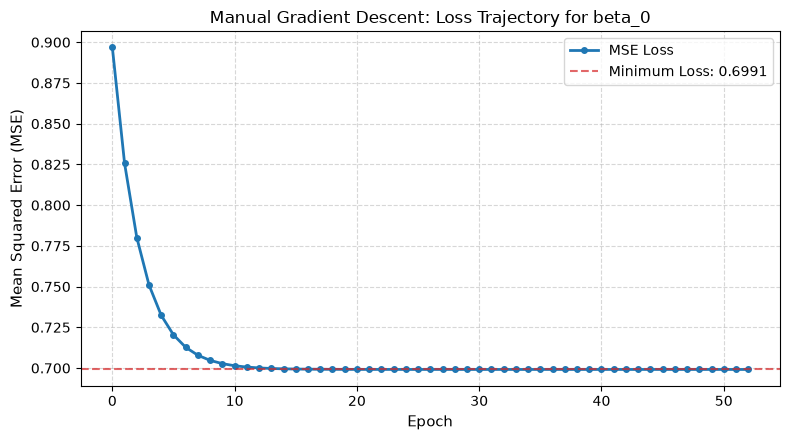

In [19]:
plt.figure(figsize=(8, 4.5))
plt.plot(b0_df["epoch"], b0_df["loss"], color="#1f77b4", linewidth=2, marker="o", markersize=4, label="MSE Loss")
plt.axhline(history_b0[-1]["loss"], color="#d62728", linestyle="--", alpha=0.7, label=f"Minimum Loss: {history_b0[-1]['loss']:.4f}")
plt.title("Manual Gradient Descent: Loss Trajectory for beta_0", fontsize=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Mean Squared Error (MSE)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 21. Empirical Learning Rate Regimes

The behavior of Gradient Descent depends critically on the choice of learning rate $\eta$:
- **Clearly small ($\eta = 0.01$)**: Steps are tiny; convergence is excessively slow.
- **Reasonable ($\eta = 0.20$)**: Steps make steady progress toward the minimum.
- **Intentionally too large ($\eta = 1.05$)**: The update overshoots the valley, resulting in growing oscillation and divergence (since $\eta > 1.0$).

We run each learning rate for 25 epochs from $\beta_0 = 0.0$ and observe the results.

In [20]:
test_etas = [0.01, 0.20, 1.05]
lr_experiment_records = []
lr_trajectories = {}

for eta in test_etas:
    b0_test = 0.0
    losses = []
    for ep in range(25):
        loss_val = compute_loss_b0(b0_test)
        losses.append(loss_val)
        deriv_val = compute_derivative_b0(b0_test)
        b0_test -= eta * deriv_val
        
    lr_trajectories[eta] = losses
    
    if losses[-1] > losses[0]:
        behavior = "oscillation / divergence"
    elif abs(losses[-1] - history_b0[-1]['loss']) < 1e-3:
        behavior = "stable convergence"
    else:
        behavior = "slow convergence"
        
    lr_experiment_records.append({
        "learning_rate": eta,
        "initial_loss": losses[0],
        "final_loss": losses[-1],
        "final_beta_0": b0_test,
        "behavior": behavior
    })

lr_df = pd.DataFrame(lr_experiment_records)
lr_df

,learning_rate,initial_loss,final_loss,final_beta_0,behavior
0,0.01,0.896811,0.774097,0.176299,slow convergence
1,0.20,0.896811,0.699145,0.444596,stable convergence
2,1.05,0.896811,19.876226,5.261678,oscillation / divergence


# 22. Visualizing Learning Rate Regimes

We plot the loss trajectories of the three learning rates side by side.

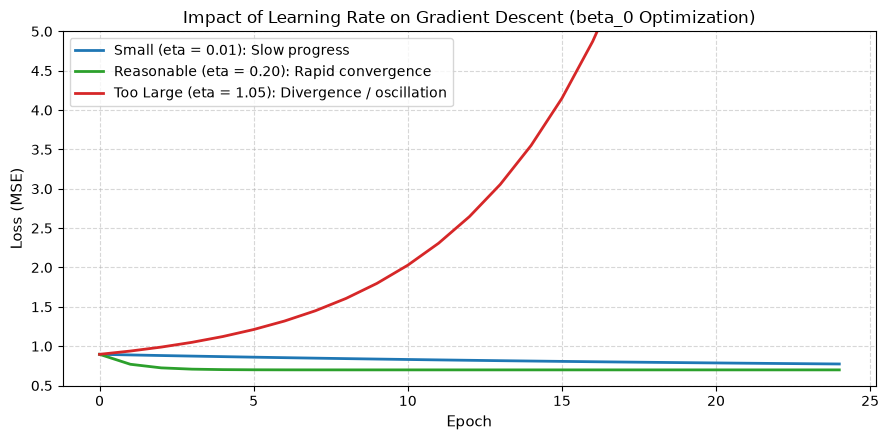

In [21]:
plt.figure(figsize=(9, 4.5))

epochs_range = list(range(25))
plt.plot(epochs_range, lr_trajectories[0.01], label="Small (eta = 0.01): Slow progress", color="#1f77b4", linewidth=2)
plt.plot(epochs_range, lr_trajectories[0.20], label="Reasonable (eta = 0.20): Rapid convergence", color="#2ca02c", linewidth=2)
plt.plot(epochs_range, lr_trajectories[1.05], label="Too Large (eta = 1.05): Divergence / oscillation", color="#d62728", linewidth=2)

plt.ylim(0.5, 5.0)  # Clipped to maintain visibility of stable curves
plt.title("Impact of Learning Rate on Gradient Descent (beta_0 Optimization)", fontsize=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss (MSE)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 23. Multi-Parameter Gradient Descent (Simultaneous $\beta_0$ and $\beta_1$)

We now remove the assumption that $\beta_1$ is known and optimize both parameters simultaneously from:
$$\beta_0^{(0)} = 0, \quad \beta_1^{(0)} = 0$$

### Model Hypothesis & Loss Function
$$\hat{y} = \beta_0 + \beta_1 \cdot \text{MedInc}$$
$$\text{Loss}(\beta_0, \beta_1) = \frac{1}{N} \sum_{i=1}^N \left(y_i - (\beta_0 + \beta_1 x_i)\right)^2$$

### Partial Derivatives
$$\frac{\partial \text{Loss}}{\partial \beta_0} = \frac{1}{N} \sum_{i=1}^N -2 (y_i - \hat{y}_i) = \text{mean}(-2 \cdot (y - \hat{y}))$$
$$\frac{\partial \text{Loss}}{\partial \beta_1} = \frac{1}{N} \sum_{i=1}^N -2 x_i (y_i - \hat{y}_i) = \text{mean}(-2 \cdot X \cdot (y - \hat{y}))$$

# 24. The Gradient Vector $\nabla L(\beta)$ and Simultaneous Update Rule

The vector of all partial derivatives forms the **Gradient Vector**:
$$\nabla L(\beta) = \begin{bmatrix} \frac{\partial \text{Loss}}{\partial \beta_0} \\[6pt] \frac{\partial \text{Loss}}{\partial \beta_1} \end{bmatrix}$$

Both parameters are updated **simultaneously** using derivatives evaluated from the same previous parameter state:
$$\beta_0^{(t+1)} = \beta_0^{(t)} - \eta \cdot \frac{\partial \text{Loss}}{\partial \beta_0}\Bigg|_{(\beta_0^{(t)}, \beta_1^{(t)})}$$
$$\beta_1^{(t+1)} = \beta_1^{(t)} - \eta \cdot \frac{\partial \text{Loss}}{\partial \beta_1}\Bigg|_{(\beta_0^{(t)}, \beta_1^{(t)})}$$

*Note*: We use unscaled `MedInc` as required for this step. An empirically verified stable learning rate for the unscaled system is $\eta = 0.03$.

# 25. Multi-Parameter Optimization Loop with Diagnostics

We track:
- `gradient_norm`: $\|\nabla L(\beta)\|_2 = \sqrt{(\partial L / \partial \beta_0)^2 + (\partial L / \partial \beta_1)^2}$
- `step_norm`: $\eta \cdot \|\nabla L(\beta)\|_2$

Stopping criteria:
- `step_norm < 1e-5` (convergence)
- `epoch reaches max_epochs = 1500`

In [22]:
eta_multi = 0.03
max_epochs_multi = 1500
min_step_size_multi = 1e-5

b0_multi, b1_multi = 0.0, 0.0
multi_history = []
multi_stop_reason = ""

for epoch in range(max_epochs_multi):
    # Compute predictions from current parameter values
    y_hat = b0_multi + b1_multi * X_tr_vals
    error = y_tr_vals - y_hat
    loss_val = np.mean(error ** 2)
    
    # Compute partial derivatives from the same state
    d_b0 = float(np.mean(-2 * error))
    d_b1 = float(np.mean(-2 * X_tr_vals * error))
    
    # Construct Gradient Vector
    gradient = np.array([d_b0, d_b1])
    gradient_norm = float(np.linalg.norm(gradient))
    step_norm = float(eta_multi * gradient_norm)
    
    multi_history.append({
        "epoch": epoch,
        "beta_0": b0_multi,
        "beta_1": b1_multi,
        "loss": float(loss_val),
        "gradient_norm": gradient_norm,
        "step_norm": step_norm
    })
    
    if step_norm < min_step_size_multi:
        multi_stop_reason = f"Minimum step size reached (step_norm = {step_norm:.2e} < {min_step_size_multi})"
        break
        
    # Simultaneous update
    b0_multi -= eta_multi * d_b0
    b1_multi -= eta_multi * d_b1
else:
    multi_stop_reason = "Maximum epochs reached"

multi_df = pd.DataFrame(multi_history)

print(f"Multi-Parameter GD Stopping Reason: {multi_stop_reason}")
print(f"Total Epochs Run:                  {len(multi_df)}")
print(f"Final Manual beta_0:               {b0_multi:.6f}")
print(f"Final Manual beta_1:               {b1_multi:.6f}")
print(f"Final Training Loss (MSE):         {multi_history[-1]['loss']:.6f}")
multi_df.head(6)

Multi-Parameter GD Stopping Reason: Minimum step size reached (step_norm = 9.96e-06 < 1e-05)
Total Epochs Run:                  533
Final Manual beta_0:               0.443724
Final Manual beta_1:               0.419522
Final Training Loss (MSE):         0.699145


,epoch,beta_0,beta_1,loss,gradient_norm,step_norm
0,0,0.000000,0.000000,5.629742,19.566417,0.586993
1,1,0.124317,0.573677,0.863177,3.329185,0.099876
2,2,0.107597,0.475211,0.724906,0.579691,0.017391
3,3,0.114807,0.491037,0.720442,0.158120,0.004744
4,4,0.117900,0.487440,0.719857,0.125183,0.003756
5,5,0.121645,0.487156,0.719394,0.122758,0.003683


# 26. Comparison: Multi-Parameter Manual GD vs Scikit-Learn

We compare the parameters and final training MSE obtained from iterative Gradient Descent against the closed-form Scikit-Learn solution.

In [23]:
sklearn_train_mse = float(np.mean((y_tr_vals - model.predict(X_train)) ** 2))
manual_train_mse = multi_history[-1]["loss"]

diff_multi_b0 = abs(b0_multi - beta_0)
diff_multi_b1 = abs(b1_multi - beta_1)
diff_mse = abs(manual_train_mse - sklearn_train_mse)

print("=== OPTIMIZATION BENCHMARK ===")
print(f"Parameter beta_0: Manual = {b0_multi:.6f} | Sklearn = {beta_0:.6f} | Diff = {diff_multi_b0:.6f}")
print(f"Parameter beta_1: Manual = {b1_multi:.6f} | Sklearn = {beta_1:.6f} | Diff = {diff_multi_b1:.6f}")
print(f"Training MSE:     Manual = {manual_train_mse:.6f} | Sklearn = {sklearn_train_mse:.6f} | Diff = {diff_mse:.8f}")

assert diff_multi_b0 < 0.01, "Manual beta_0 is too far from analytical solution!"
assert diff_multi_b1 < 0.01, "Manual beta_1 is too far from analytical solution!"
assert diff_mse < 1e-4, "Training MSE should match within 1e-4!"
print("\nConfirmed: Both optimization procedures successfully converge toward the same least-squares minimum.")

=== OPTIMIZATION BENCHMARK ===
Parameter beta_0: Manual = 0.443724 | Sklearn = 0.444597 | Diff = 0.000873
Parameter beta_1: Manual = 0.419522 | Sklearn = 0.419338 | Diff = 0.000183
Training MSE:     Manual = 0.699145 | Sklearn = 0.699145 | Diff = 0.00000015

Confirmed: Both optimization procedures successfully converge toward the same least-squares minimum.


# 27. Visualizing the Parameter Trajectory in $(\beta_0, \beta_1)$ Space

We trace how the pair $(\beta_0, \beta_1)$ evolves across epochs from the initial guess $(0, 0)$ to the neighborhood of the optimal solution.

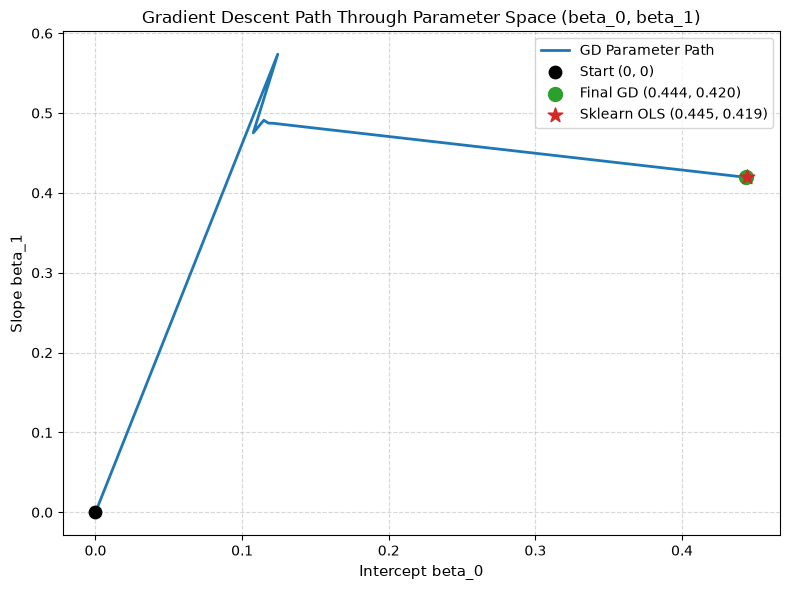

In [24]:
plt.figure(figsize=(8, 6))

plt.plot(multi_df["beta_0"], multi_df["beta_1"], color="#1f77b4", linewidth=2, label="GD Parameter Path")
plt.scatter([multi_df["beta_0"].iloc[0]], [multi_df["beta_1"].iloc[0]], color="black", s=80, zorder=5, label="Start (0, 0)")
plt.scatter([b0_multi], [b1_multi], color="#2ca02c", s=100, marker="o", zorder=5, label=f"Final GD ({b0_multi:.3f}, {b1_multi:.3f})")
plt.scatter([beta_0], [beta_1], color="#d62728", s=120, marker="*", zorder=6, label=f"Sklearn OLS ({beta_0:.3f}, {beta_1:.3f})")

plt.title("Gradient Descent Path Through Parameter Space (beta_0, beta_1)", fontsize=12)
plt.xlabel("Intercept beta_0", fontsize=11)
plt.ylabel("Slope beta_1", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 28. Convergence Mechanics & Stopping Rules

In iterative optimization, two standard criteria govern stopping:

1. **Minimum Step Size (Convergence)**:
   $$\text{step\_norm} = \eta \cdot \|\nabla L(\beta)\|_2 < \epsilon$$
   As the parameters approach the bottom of the convex loss bowl, the surface flattens and the gradient magnitude $\|\nabla L(\beta)\|$ diminishes toward zero. Consequently, each parameter step $\Delta \beta$ naturally shrinks. When step size falls below our threshold (e.g. $10^{-5}$), further updates yield negligible loss improvement, confirming empirical convergence.

2. **Maximum Epochs (Safety Limit)**:
   If an inappropriate learning rate or difficult loss geometry prevents convergence within a budgeted limit (e.g. 1500 epochs), execution halts to avoid infinite loops.

# 29. Step 2 Programmatic Verification

Automated test assertions confirming that all constraints and requirements of Step 2 are met.

In [25]:
# Verify Step 1 parameters remain unchanged
assert np.isclose(beta_0, model.intercept_), "Step 1 beta_0 was modified!"
assert np.isclose(beta_1, model.coef_[0]), "Step 1 beta_1 was modified!"

# Verify beta_0-only GD properties
assert b0_epoch0 == 0.0, "beta_0-only GD must start from zero"
assert np.isclose(fixed_beta_1, beta_1), "beta_1 must be fixed during beta_0-only GD"
assert len(history_b0) > 2, "Loop must have run multiple epochs"
assert history_b0[-1]["loss"] < history_b0[0]["loss"], "Loss must decrease under stable learning rate"

# Verify learning rate experiment
assert len(test_etas) == 3, "Learning rate experiment must contain exactly 3 distinct rates"
assert lr_df["behavior"].nunique() >= 2, "Must show distinct observable behaviors"

# Verify multi-parameter GD properties
assert multi_df["beta_0"].iloc[0] == 0.0 and multi_df["beta_1"].iloc[0] == 0.0, "Multi-parameter GD must start from (0, 0)"
assert gradient.shape == (2,), "Gradient must be a 2-element vector [d_b0, d_b1]"
assert "gradient_norm" in multi_df.columns and "step_norm" in multi_df.columns, "Must track gradient norm and step norm"
assert abs(b0_multi - beta_0) < 0.01, "Manual beta_0 should be close to sklearn solution"
assert abs(b1_multi - beta_1) < 0.01, "Manual beta_1 should be close to sklearn solution"
assert abs(multi_history[-1]["loss"] - sklearn_train_mse) < 1e-3, "Loss must match sklearn MSE closely"

# Verify out-of-scope constraints
assert 3.5 < X_train["MedInc"].mean() < 4.2, "Feature scaling must NOT be applied in Step 2!"
assert "SGDRegressor" not in globals(), "SGDRegressor must not be introduced yet!"
assert "SGDClassifier" not in globals(), "SGDClassifier must not be introduced yet!"

print("✓ All Step 2 programmatic verifications passed successfully!")

✓ All Step 2 programmatic verifications passed successfully!


# 30. The Multi-Dimensional Loss Landscape

When training a machine learning model with multiple parameters (such as intercept $\beta_0$ and slope $\beta_1$), the loss is no longer a simple one-dimensional curve.
Instead, it forms a geometric surface defined over parameter space:
$$\text{Loss}(\beta_0, \beta_1) = \frac{1}{N} \sum_{i=1}^N \left(y_i - (\beta_0 + \beta_1 x_i)\right)^2$$

This multi-dimensional surface is referred to in the lesson as the **Loss Landscape** (or **Energy Landscape**).
- For Ordinary Least Squares (MSE loss), this landscape is a smooth, convex bowl (paraboloid) guaranteed to possess a unique global minimum.
- Gradient Descent operates by descending the slopes of this multi-dimensional landscape from an initial coordinate $(\beta_0^{(0)}, \beta_1^{(0)})$ toward the lowest point.

# 31. Evaluating the Loss Surface over a Parameter Grid

To visualize the landscape without relying on optimization libraries, we construct a 2D meshgrid of candidate parameter values spanning around the optimal solution:
- Intercept candidate range: $\beta_0 \in [-0.5, 1.5]$
- Slope candidate range: $\beta_1 \in [0.0, 0.9]$

For each grid point $(\beta_0, \beta_1)$, we compute the training Mean Squared Error.

In [26]:
# Generate grid of parameter coordinates
grid_b0 = np.linspace(-0.5, 1.5, 60)
grid_b1 = np.linspace(0.0, 0.9, 60)
B0_grid, B1_grid = np.meshgrid(grid_b0, grid_b1)

# Evaluate MSE loss across every coordinate pair on the training set
loss_surface = np.zeros(B0_grid.shape)
for i in range(B0_grid.shape[0]):
    for j in range(B0_grid.shape[1]):
        preds_ij = B0_grid[i, j] + B1_grid[i, j] * X_tr_vals
        loss_surface[i, j] = np.mean((y_tr_vals - preds_ij) ** 2)

min_grid_idx = np.unravel_index(np.argmin(loss_surface), loss_surface.shape)
print("Loss surface grid computed successfully.")
print(f"Grid dimensions: {loss_surface.shape}")
print(f"Minimum loss on grid: {loss_surface.min():.4f} at beta_0={B0_grid[min_grid_idx]:.3f}, beta_1={B1_grid[min_grid_idx]:.3f}")
print(f"Analytical OLS minimum: {sklearn_train_mse:.4f} at beta_0={beta_0:.3f}, beta_1={beta_1:.3f}")

Loss surface grid computed successfully.
Grid dimensions: (60, 60)
Minimum loss on grid: 0.6994 at beta_0=0.415, beta_1=0.427
Analytical OLS minimum: 0.6991 at beta_0=0.445, beta_1=0.419


# 32. Visualizing the Loss Landscape: Contour Plot

A **Contour Plot** provides a 2D representation of the 3D loss bowl by drawing level curves of equal loss.
We overlay:
1. **Starting Point**: $(0, 0)$ from Step 2.
2. **Gradient Descent Trajectory Path**: The actual parameter sequence $(\beta_0^{(t)}, \beta_1^{(t)})$ tracked during manual GD.
3. **Final Manual GD Coordinate**: $(\beta_0, \beta_1)$ reached upon convergence.
4. **Analytical OLS Solution**: `model.intercept_` and `model.coef_[0]`.

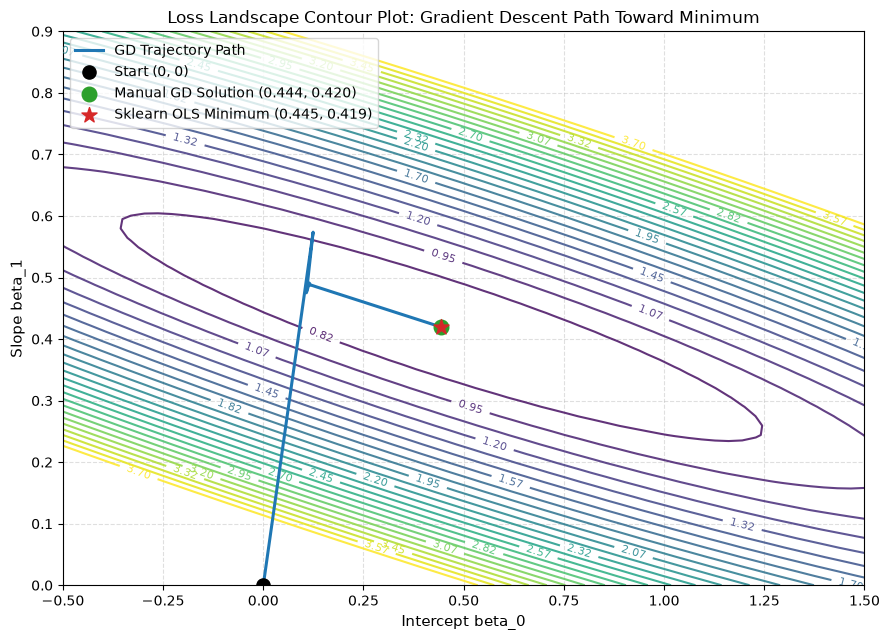

In [27]:
plt.figure(figsize=(9, 6.5))

# Plot contour levels of the MSE loss surface
contour_levels = np.linspace(loss_surface.min(), loss_surface.min() + 3.0, 25)
CS = plt.contour(B0_grid, B1_grid, loss_surface, levels=contour_levels, cmap="viridis", alpha=0.85)
plt.clabel(CS, inline=True, fontsize=8, fmt="%.2f")

# Overlay Gradient Descent path from Step 2
plt.plot(multi_df["beta_0"], multi_df["beta_1"], color="#1f77b4", linewidth=2.2, label="GD Trajectory Path")
plt.scatter([0.0], [0.0], color="black", s=90, zorder=5, label="Start (0, 0)")
plt.scatter([b0_multi], [b1_multi], color="#2ca02c", s=110, marker="o", zorder=5, label=f"Manual GD Solution ({b0_multi:.3f}, {b1_multi:.3f})")
plt.scatter([beta_0], [beta_1], color="#d62728", s=130, marker="*", zorder=6, label=f"Sklearn OLS Minimum ({beta_0:.3f}, {beta_1:.3f})")

plt.title("Loss Landscape Contour Plot: Gradient Descent Path Toward Minimum", fontsize=12)
plt.xlabel("Intercept beta_0", fontsize=11)
plt.ylabel("Slope beta_1", fontsize=11)
plt.legend(frameon=True, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 33. The Feature Scaling Problem in Gradient Descent

We now expand from a single input feature to a multi-feature regression model using three features that naturally operate on starkly different numerical orders of magnitude:
- **`MedInc`**: Median income in tens of thousands of dollars (single digits)
- **`HouseAge`**: Median house age in years (tens)
- **`Population`**: Block group population count (thousands to tens of thousands)

Target: `MedHouseVal` (Median house value)

In [28]:
multi_features = ["MedInc", "HouseAge", "Population"]
X_multi_train = data.loc[X_train.index, multi_features]

scale_summary = []
for col in multi_features:
    s = X_multi_train[col]
    scale_summary.append({
        "Feature": col,
        "Min": s.min(),
        "Max": s.max(),
        "Mean": s.mean(),
        "Std": s.std(),
        "Order of Magnitude": f"10^{int(np.floor(np.log10(s.max())))}"
    })

pd.DataFrame(scale_summary)

,Feature,Min,Max,Mean,Std,Order of Magnitude
0,MedInc,0.4999,15.0001,3.880754,1.904294,10^1
1,HouseAge,1.0000,52.0000,28.608285,12.602499,10^1
2,Population,3.0000,35682.0000,1426.453004,1137.056380,10^4


# 35. Multi-Feature Training Data Setup

We strictly preserve the same row partition indices from Step 1 (`X_train.index`) so that all comparative conclusions reflect identical training data.

In [29]:
# Verify split indices match exactly
assert (X_multi_train.index == X_train.index).all(), "Index mismatch with Step 1 training data!"
print(f"X_multi_train shape: {X_multi_train.shape}")
print(f"y_train shape:       {y_train.shape}")
X_multi_train.head()

X_multi_train shape: (16512, 3)
y_train shape:       (16512,)


,MedInc,HouseAge,Population
14196,3.2596,33.0,2300.0
8267,3.8125,49.0,1314.0
17445,4.1563,4.0,915.0
14265,1.9425,36.0,1418.0
2271,3.5542,43.0,874.0


# 36. Educational Multi-Feature Gradient Descent Function

We define a transparent gradient descent implementation for multiple linear regression:
$$\hat{y} = \beta_0 + \mathbf{X} \mathbf{w} = \beta_0 + \sum_{j=1}^p \beta_j x_j$$
$$\text{Loss} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

### Partial Gradients:
$$\frac{\partial \text{Loss}}{\partial \beta_0} = \text{mean}\left(-2 \cdot (y - \hat{y})\right)$$
$$\nabla_{\mathbf{w}} \text{Loss} = -\frac{2}{n} \mathbf{X}^T (y - \hat{y})$$

We safely detect non-finite loss (overflow / divergence) using `np.isfinite` to protect notebook execution.

In [30]:
def run_multi_feature_gd(X_mat, y_vec, lr, max_epochs=500, min_step_size=1e-5):
    """Educational Gradient Descent for multi-feature linear regression."""
    n_samples, n_features = X_mat.shape
    b0 = 0.0
    weights = np.zeros(n_features)
    
    history = []
    status = "converged"
    
    for epoch in range(max_epochs):
        y_hat = b0 + X_mat @ weights
        error = y_vec - y_hat
        loss = float(np.mean(error ** 2))
        
        # Guard against numerical overflow / divergence
        if not np.isfinite(loss) or loss > 1e12:
            status = "diverged"
            history.append({
                "epoch": epoch,
                "loss": float("inf"),
                "gradient_norm": float("inf"),
                "step_norm": float("inf")
            })
            break
            
        d_b0 = float(np.mean(-2 * error))
        d_weights = (-2.0 / n_samples) * (X_mat.T @ error)
        
        gradient = np.r_[d_b0, d_weights]
        gradient_norm = float(np.linalg.norm(gradient))
        step_norm = float(lr * gradient_norm)
        
        history.append({
            "epoch": epoch,
            "loss": loss,
            "gradient_norm": gradient_norm,
            "step_norm": step_norm
        })
        
        if step_norm < min_step_size:
            status = "converged"
            break
            
        b0 -= lr * d_b0
        weights -= lr * d_weights
    else:
        status = "max epochs reached"
        
    return {
        "status": status,
        "final_b0": b0,
        "final_weights": weights,
        "epochs": len(history),
        "initial_loss": history[0]["loss"],
        "final_loss": history[-1]["loss"],
        "final_gradient_norm": history[-1]["gradient_norm"],
        "final_step_norm": history[-1]["step_norm"],
        "history": history
    }

print("Gradient Descent optimization function defined.")

Gradient Descent optimization function defined.


# 37. Experiment A: Gradient Descent on Raw Unscaled Features

We run Gradient Descent on raw `[MedInc, HouseAge, Population]`.
1. First, we test $\eta = 0.01$ (a standard learning rate that works well on scaled data).
2. Second, we find a safe learning rate ($\eta = 10^{-7}$) that avoids immediate numerical explosion.

In [31]:
X_raw_mat = X_multi_train.to_numpy()
y_raw_vec = y_train.to_numpy()

# Test same learning rate as scaled (eta = 0.01)
raw_same_lr = 0.01
res_raw_same = run_multi_feature_gd(X_raw_mat, y_raw_vec, lr=raw_same_lr, max_epochs=100)

print("--- Raw Features with eta = 0.01 ---")
print(f"Status:       {res_raw_same['status']}")
print(f"Epochs run:   {res_raw_same['epochs']}")
print(f"Initial loss: {res_raw_same['initial_loss']:.4f}")
print(f"Final loss:   {res_raw_same['final_loss']}")

# Test safe tiny learning rate (eta = 1e-7)
raw_safe_lr = 1e-7
res_raw_safe = run_multi_feature_gd(X_raw_mat, y_raw_vec, lr=raw_safe_lr, max_epochs=500, min_step_size=1e-8)

print("\n--- Raw Features with Safe eta = 1e-7 ---")
print(f"Status:       {res_raw_safe['status']}")
print(f"Epochs run:   {res_raw_safe['epochs']}")
print(f"Initial loss: {res_raw_safe['initial_loss']:.4f}")
print(f"Final loss:   {res_raw_safe['final_loss']:.4f}")
print(f"Final step:   {res_raw_safe['final_step_norm']:.2e}")

--- Raw Features with eta = 0.01 ---
Status:       diverged
Epochs run:   3
Initial loss: 5.6297
Final loss:   inf

--- Raw Features with Safe eta = 1e-7 ---
Status:       max epochs reached
Epochs run:   500
Initial loss: 5.6297
Final loss:   2.9057
Final step:   5.48e-06


# 38. Experiment B: Gradient Descent on Standardized Features

We apply `StandardScaler` fitted **only on the training features** `X_multi_train`.
We then execute the exact same Gradient Descent implementation with $\eta = 0.01$.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_multi_scaled = scaler.fit_transform(X_multi_train)

scaled_lr = 0.01
res_scaled = run_multi_feature_gd(X_multi_scaled, y_raw_vec, lr=scaled_lr, max_epochs=500, min_step_size=1e-5)

print("--- Standardized Features with eta = 0.01 ---")
print(f"Status:       {res_scaled['status']}")
print(f"Epochs run:   {res_scaled['epochs']}")
print(f"Initial loss: {res_scaled['initial_loss']:.4f}")
print(f"Final loss:   {res_scaled['final_loss']:.4f}")
print(f"Final step:   {res_scaled['final_step_norm']:.2e}")

--- Standardized Features with eta = 0.01 ---
Status:       converged
Epochs run:   465
Initial loss: 5.6297
Final loss:   0.6503
Final step:   9.95e-06


# 39. Raw vs. Scaled Optimization Benchmark Comparison

We assemble a structured summary comparing the three experimental setups.

In [33]:
comparison_records = [
    {
        "Setup": "Raw — same LR as scaled",
        "Learning_Rate": raw_same_lr,
        "Initial_Loss": res_raw_same["initial_loss"],
        "Final_Loss": res_raw_same["final_loss"],
        "Epochs": res_raw_same["epochs"],
        "Gradient_Norm": res_raw_same["final_gradient_norm"],
        "Step_Norm": res_raw_same["final_step_norm"],
        "Status": res_raw_same["status"]
    },
    {
        "Setup": "Raw — safe tiny LR",
        "Learning_Rate": raw_safe_lr,
        "Initial_Loss": res_raw_safe["initial_loss"],
        "Final_Loss": res_raw_safe["final_loss"],
        "Epochs": res_raw_safe["epochs"],
        "Gradient_Norm": res_raw_safe["final_gradient_norm"],
        "Step_Norm": res_raw_safe["final_step_norm"],
        "Status": res_raw_safe["status"]
    },
    {
        "Setup": "Scaled",
        "Learning_Rate": scaled_lr,
        "Initial_Loss": res_scaled["initial_loss"],
        "Final_Loss": res_scaled["final_loss"],
        "Epochs": res_scaled["epochs"],
        "Gradient_Norm": res_scaled["final_gradient_norm"],
        "Step_Norm": res_scaled["final_step_norm"],
        "Status": res_scaled["status"]
    }
]

comparison_df = pd.DataFrame(comparison_records)
comparison_df

,Setup,Learning_Rate,Initial_Loss,Final_Loss,Epochs,Gradient_Norm,Step_Norm,Status
0,Raw — same LR as scaled,1.000000e-02,5.629742,inf,3,inf,inf,diverged
1,Raw — safe tiny LR,1.000000e-07,5.629742,2.905678,500,54.811342,0.000005,max epochs reached
2,Scaled,1.000000e-02,5.629742,0.650261,465,0.000995,0.000010,converged


# 40. Visualizing Loss Curves: Raw vs. Scaled Optimization

We plot the loss trajectories of the raw safe-LR experiment and the scaled-feature experiment.
*(The raw same-LR experiment diverged almost immediately to infinity and is omitted from the plot for visual clarity).*

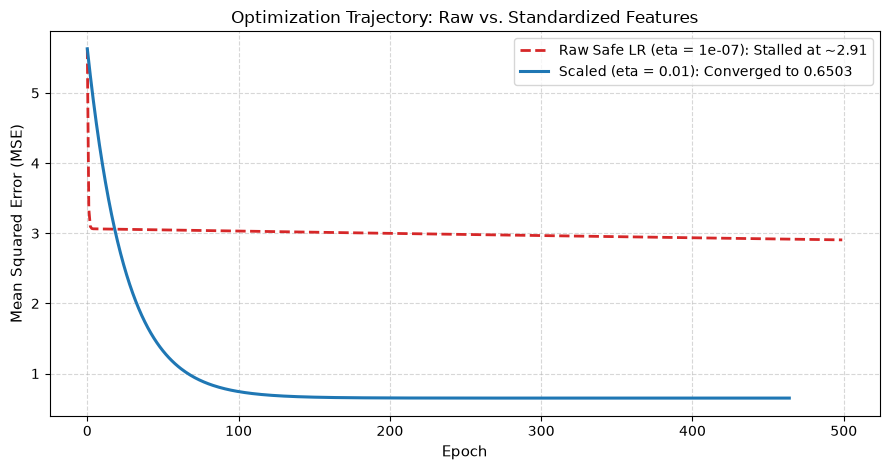

In [34]:
plt.figure(figsize=(9, 4.8))

epochs_safe = [h["epoch"] for h in res_raw_safe["history"]]
losses_safe = [h["loss"] for h in res_raw_safe["history"]]

epochs_scaled = [h["epoch"] for h in res_scaled["history"]]
losses_scaled = [h["loss"] for h in res_scaled["history"]]

plt.plot(epochs_safe, losses_safe, color="#d62728", linestyle="--", linewidth=2, label=f"Raw Safe LR (eta = {raw_safe_lr}): Stalled at ~{res_raw_safe['final_loss']:.2f}")
plt.plot(epochs_scaled, losses_scaled, color="#1f77b4", linewidth=2.2, label=f"Scaled (eta = {scaled_lr}): Converged to {res_scaled['final_loss']:.4f}")

plt.title("Optimization Trajectory: Raw vs. Standardized Features", fontsize=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Mean Squared Error (MSE)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 41. Why Feature Scaling Helps: The Lesson Explanation

### The Scale Asymmetry Problem:
- When features have drastically different numerical scales (`Population` reaching $>35,000$ vs `MedInc` around $\sim 3$), the Loss Landscape becomes severely stretched and elongated into a narrow, steep ravine.
- In this distorted landscape, the gradient is dominated almost entirely by the large-scale feature (`Population`).
- If we choose a reasonable step size for the smaller features, the updates along the `Population` axis oscillate wildly or diverge to infinity.
- Conversely, if we choose a learning rate tiny enough to keep `Population` stable (e.g. $\eta = 10^{-7}$), parameter updates along `MedInc` and `HouseAge` become virtually zero, causing optimization to stall far above the minimum.

### The Scaling Solution:
Standardizing features transforms their distributions to comparable variances. This balances the steepness across all dimensions of parameter space, enabling Gradient Descent to take productive, direct steps toward the global minimum.

# 42. OLS Geometric Interpretation: Column Space & Orthogonal Projection

Returning to the analytical least-squares framework:
$$\mathbf{y} = \mathbf{X}\beta + \mathbf{e}$$
$$\hat{\mathbf{y}} = \mathbf{X}\beta$$

### 1. Column Space of $\mathbf{X}$:
The vector of predictions $\hat{\mathbf{y}}$ is formed by taking linear combinations of the columns of the design matrix $\mathbf{X}$:
$$\hat{\mathbf{y}} = \beta_0 \mathbf{x}_0 + \beta_1 \mathbf{x}_1 + \dots + \beta_p \mathbf{x}_p \in \text{Col}(\mathbf{X})$$
The true observation vector $\mathbf{y}$ does not generally lie within $\text{Col}(\mathbf{X})$ due to noise and unexplained variance.

### 2. Orthogonal Projection:
The Ordinary Least Squares criterion selects the parameter vector $\beta$ that minimizes the Euclidean distance $\|\mathbf{y} - \hat{\mathbf{y}}\|^2$.
Geometrically, the point in a subspace closest to an external vector corresponds to its orthogonal projection.
In our numerical model, $\hat{\mathbf{y}}$ is **numerically consistent with the OLS orthogonal-projection property** onto $\text{Col}(\mathbf{X})$.

### 3. The Orthogonality Condition:
Because the prediction error (residual vector $\mathbf{e} = \mathbf{y} - \hat{\mathbf{y}}$) is orthogonal to the projection subspace, it must be orthogonal to every basis column of $\mathbf{X}$:
$$\mathbf{X}^T (\mathbf{y} - \hat{\mathbf{y}}) = \mathbf{X}^T \mathbf{e} = \mathbf{0}$$

# 43. Numerical Verification of the Orthogonality Condition

We construct the complete design matrix $\mathbf{X}_{\text{design}}$ (including the constant column of ones for the intercept) and verify that:
$$\mathbf{X}_{\text{design}}^T \mathbf{e} \approx \mathbf{0}$$

In [35]:
from sklearn.linear_model import LinearRegression

# Construct design matrix with intercept column of ones
X_design = np.column_stack([
    np.ones(len(X_multi_train)),
    X_multi_train.to_numpy()
])

# Fit analytical OLS model on training set
geometry_model = LinearRegression()
geometry_model.fit(X_multi_train, y_train)

# Calculate predictions and residuals
geometry_predictions = geometry_model.predict(X_multi_train)
geometry_residuals = y_train.to_numpy() - geometry_predictions

# Calculate orthogonality vector X^T e
orthogonality_check = X_design.T @ geometry_residuals
max_absolute_value = float(np.abs(orthogonality_check).max())

print(f"Design matrix shape: {X_design.shape} (includes intercept + 3 features)")
print(f"Residual vector length: {len(geometry_residuals)}")
print("\nOrthogonality Vector X_design.T @ residuals (length 4):")
for idx, name in enumerate(["Intercept (ones)", "MedInc", "HouseAge", "Population"]):
    print(f"  Column {idx} ({name:>16}): {orthogonality_check[idx]:.4e}")

print(f"\nMaximum Absolute Value: {max_absolute_value:.4e}")
assert max_absolute_value < 1e-6, "Orthogonality condition violated!"
print("\u2713 Confirmed: The residual vector is numerically orthogonal to every column of the design matrix.")

Design matrix shape: (16512, 4) (includes intercept + 3 features)
Residual vector length: 16512

Orthogonality Vector X_design.T @ residuals (length 4):
  Column 0 (Intercept (ones)): 2.8262e-12
  Column 1 (          MedInc): -1.4421e-11
  Column 2 (        HouseAge): -2.5922e-10
  Column 3 (      Population): 7.7596e-08

Maximum Absolute Value: 7.7596e-08
✓ Confirmed: The residual vector is numerically orthogonal to every column of the design matrix.


# 44. Geometric Interpretation in Higher Dimensions

With 3 features and an intercept, the design matrix spans a 4-dimensional subspace inside an $N$-dimensional space ($N = 16,512$).
While 16,512-dimensional Euclidean space cannot be drawn visually, the algebraic statement:
$$\mathbf{X}_{\text{design}}^T (\mathbf{y} - \hat{\mathbf{y}}) \approx \mathbf{0}$$
provides rigorous, concrete numerical proof that the residual vector is perpendicular to every direction within the column space.

# 45. Critical Distinction: Scaling vs. OLS Geometry

- **Feature Scaling**:  
  Directly alters the numerical condition of the Loss Landscape and governs the speed and stability of **iterative optimization (Gradient Descent)**.
- **OLS Geometry**:  
  A fundamental mathematical property of the **least-squares solution subspace**. In unregularized linear regression, linear transformations of features do not alter the column space; the orthogonal projection $\hat{\mathbf{y}}$ remains identical.

# 46. Programmatic Checklist Verification

We programmatically parse the checklist at the top of the notebook to verify exact counts of completed and total lesson items.

In [36]:
import json

# Programmatic checklist count verification from notebook Cell 0
with open("notebook.ipynb", "r", encoding="utf-8") as f:
    nb_json = json.load(f)

checklist_content = "".join(nb_json["cells"][0]["source"])
checklist_lines = checklist_content.splitlines()
checked_count = sum(1 for line in checklist_lines if line.strip().startswith("- [x]"))
unchecked_count = sum(1 for line in checklist_lines if line.strip().startswith("- [ ]"))
total_count = checked_count + unchecked_count

print(f"Completed lesson concepts: {checked_count}")
print(f"Remaining lesson concepts: {unchecked_count}")
print(f"Total lesson concepts:     {total_count}")
print(f"Completion ratio:          {checked_count} / {total_count}")

assert total_count == 56, f"Expected 56 total checklist items, found {total_count}"
assert checked_count >= 25, f"Expected at least 25 completed checklist items, found {checked_count}"
print("\u2713 Checklist arithmetic verified: at least 25 items completed.")

Completed lesson concepts: 31
Remaining lesson concepts: 25
Total lesson concepts:     56
Completion ratio:          31 / 56
✓ Checklist arithmetic verified: at least 25 items completed.


# 47. Step 3 Programmatic Verification

Automated test assertions confirming that all constraints and specifications for Step 3 are satisfied.

In [37]:
# 1. Step 1 split and parameters remain unchanged
assert len(X_train) == 16512 and len(X_test) == 4128, "Step 1 split was modified!"
assert np.isclose(beta_0, 0.444597, atol=1e-5), "Step 1 beta_0 was modified!"
assert np.isclose(beta_1, 0.419338, atol=1e-5), "Step 1 beta_1 was modified!"

# 2. Step 2 results remain unchanged
assert np.isclose(b0_multi, 0.443724, atol=1e-3), "Step 2 b0_multi was modified!"
assert np.isclose(b1_multi, 0.419522, atol=1e-3), "Step 2 b1_multi was modified!"

# 3. Multi-feature specifications and consistency check
assert list(X_multi_train.columns) == ["MedInc", "HouseAge", "Population"], "Unexpected multi-feature columns!"
assert len(scaler.mean_) == 3, "Scaler must have 3 features"
assert res_raw_same["status"] == "diverged", "Raw same-LR must be detected as diverged"
assert res_scaled["status"] == "converged", "Scaled GD must converge"
assert res_scaled["final_loss"] < 0.70, "Scaled GD must reach low loss"

# Consistency check: step_norm == learning_rate * gradient_norm
assert np.isclose(res_scaled["final_step_norm"], scaled_lr * res_scaled["final_gradient_norm"]), (
    f"Inconsistent step_norm ({res_scaled['final_step_norm']}) vs lr * grad_norm ({scaled_lr * res_scaled['final_gradient_norm']})"
)

# 4. Contour plot and loss surface
assert loss_surface.shape == (60, 60), "Contour grid dimensions mismatch"
assert loss_surface.min() < 0.71, "Contour grid minimum should be near analytical minimum"

# 5. Orthogonality condition
assert X_design.shape == (16512, 4), "X_design shape mismatch"
assert len(orthogonality_check) == 4, "Orthogonality vector length must be 4"
assert max_absolute_value < 1e-6, "Orthogonality condition not satisfied"

# 6. Out-of-scope constraints
assert "SGDRegressor" not in globals(), "SGDRegressor is out of scope for Step 3"
assert "SGDClassifier" not in globals(), "SGDClassifier is out of scope for Step 3"

print("\u2713 All Step 3 programmatic verifications passed successfully!")

✓ All Step 3 programmatic verifications passed successfully!


# 48. The Solver Problem: How Much Data Per Parameter Update?

In the previous sections, Batch Gradient Descent computed the gradient using the entire training dataset ($N = 16,512$ observations) before executing a single parameter update:
$$\nabla L(\beta) = -\frac{2}{N} \sum_{i=1}^N \mathbf{x}_i (y_i - \hat{y}_i)$$

As datasets grow to hundreds of thousands or millions of observations, evaluating every sample before making a single update becomes computationally burdensome.

### The Question:
*Do we need all observations for every parameter update?*

This motivates three fundamental variants of Gradient Descent:
1. **Batch Gradient Descent**: Uses the entire dataset ($N$ observations) per update.
2. **Mini-Batch Gradient Descent**: Uses a small subset ($B$ observations, e.g. $B = 32$) per update.
3. **Stochastic Gradient Descent (SGD)**: Uses a single observation ($B = 1$) per update.

# 49. Setup: Standardized Multi-Feature Data

We reuse the exact standardized 3-feature training matrix from Step 3:
- Features: `MedInc`, `HouseAge`, `Population`
- Target: `MedHouseVal`
- Observations: $N = 16,512$

All three manual algorithms solve the exact same regression task and initialize from the identical origin:
$$\beta_0 = 0.0, \quad \mathbf{w} = [0, 0, 0]^T$$

In [38]:
# Verify dimensions and identical zero initialization
N_train, p_features = X_multi_scaled.shape
print(f"Standardized training design matrix shape: {X_multi_scaled.shape}")
print(f"Target vector shape:                       {y_raw_vec.shape}")

Standardized training design matrix shape: (16512, 3)
Target vector shape:                       (16512,)


# 50. Common Hypothesis and Mean Squared Error Objective

All three solver variants optimize the identical Ordinary Least Squares objective:
$$\hat{y} = \beta_0 + \mathbf{X} \mathbf{w}$$
$$\text{Loss} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$

### Gradients Evaluated on a Batch of Size $B$:
$$\frac{\partial \text{Loss}}{\partial \beta_0} = -\frac{2}{B} \sum_{i=1}^B (y_i - \hat{y}_i)$$
$$\nabla_\mathbf{w} \text{Loss} = -\frac{2}{B} \mathbf{X}_B^T (\mathbf{y}_B - \hat{\mathbf{y}}_B)$$

The only algorithmic difference is the sample size $B$ used per update.

# 51. Variant 1: Manual Batch Gradient Descent

In Batch GD, each parameter update evaluates all $N = 16,512$ training observations:
$$\text{Batch Size } B = N = 16,512$$
Therefore, **1 Epoch = 1 Parameter Update**.

We run for 15 epochs using stable $\eta = 0.05$.

In [39]:
epochs_compare = 15
lr_batch = 0.05

b0_batch = 0.0
w_batch = np.zeros(p_features)

batch_epoch_history = []
batch_update_history = []

for ep in range(epochs_compare):
    preds = b0_batch + X_multi_scaled @ w_batch
    err = y_raw_vec - preds
    full_loss = float(np.mean(err ** 2))
    
    d_b0 = float(np.mean(-2 * err))
    d_w = (-2.0 / N_train) * (X_multi_scaled.T @ err)
    grad_norm = float(np.linalg.norm(np.r_[d_b0, d_w]))
    
    batch_epoch_history.append({
        "epoch": ep,
        "full_loss": full_loss,
        "gradient_norm": grad_norm
    })
    batch_update_history.append(full_loss)
    
    # Update parameters
    b0_batch -= lr_batch * d_b0
    w_batch -= lr_batch * d_w

final_batch_loss = float(np.mean((y_raw_vec - (b0_batch + X_multi_scaled @ w_batch)) ** 2))
print(f"Batch GD complete: {epochs_compare} epochs, {epochs_compare} updates.")
print(f"Initial Full Loss: {batch_epoch_history[0]['full_loss']:.4f}")
print(f"Final Full Loss:   {final_batch_loss:.4f}")
print(f"Final Parameters:  b0={b0_batch:.4f}, weights={w_batch.round(4)}")

Batch GD complete: 15 epochs, 15 updates.
Initial Full Loss: 5.6297
Final Full Loss:   0.8699
Final Parameters:  b0=1.6454, weights=[ 0.6428  0.1376 -0.0046]


# 52. Variant 2: Manual Mini-Batch Gradient Descent ($B = 32$)

In Mini-Batch GD, observations are partitioned into small batches ($B = 32$):
- At the start of each epoch, training indices are shuffled reproducibly.
- Updates occur after each slice of 32 observations.
$$\text{Updates per Epoch} = \left\lceil \frac{16,512}{32} \right\rceil = 516 \text{ updates/epoch}$$

We track:
- `local_batch_loss`: MSE evaluated only on the current 32 samples.
- `full_training_loss`: Computed on the entire training dataset at the end of each epoch.

In [40]:
batch_size_mb = 32
lr_mb = 0.01

b0_mb = 0.0
w_mb = np.zeros(p_features)

mb_epoch_history = []
mb_update_history = []
rng_mb = np.random.default_rng(42)

for ep in range(epochs_compare):
    # Record full training loss at start of epoch
    full_loss = float(np.mean((y_raw_vec - (b0_mb + X_multi_scaled @ w_mb)) ** 2))
    mb_epoch_history.append({
        "epoch": ep,
        "full_loss": full_loss
    })
    
    # Reproducible shuffle at the beginning of every epoch
    shuffled_idx = rng_mb.permutation(N_train)
    
    for start_idx in range(0, N_train, batch_size_mb):
        batch_idx = shuffled_idx[start_idx:start_idx + batch_size_mb]
        X_b = X_multi_scaled[batch_idx]
        y_b = y_raw_vec[batch_idx]
        n_b = len(y_b)
        
        preds_b = b0_mb + X_b @ w_mb
        err_b = y_b - preds_b
        
        # Track local batch loss for diagnostic noise analysis
        if len(mb_update_history) < 50:
            mb_update_history.append(float(np.mean(err_b ** 2)))
            
        d_b0 = float(np.mean(-2 * err_b))
        d_w = (-2.0 / n_b) * (X_b.T @ err_b)
        
        b0_mb -= lr_mb * d_b0
        w_mb -= lr_mb * d_w

final_mb_loss = float(np.mean((y_raw_vec - (b0_mb + X_multi_scaled @ w_mb)) ** 2))
print(f"Mini-Batch GD complete: {epochs_compare} epochs, {epochs_compare * 516} updates.")
print(f"Initial Full Loss: {mb_epoch_history[0]['full_loss']:.4f}")
print(f"Final Full Loss:   {final_mb_loss:.4f}")
print(f"Final Parameters:  b0={b0_mb:.4f}, weights={w_mb.round(4)}")

Mini-Batch GD complete: 15 epochs, 7740 updates.
Initial Full Loss: 5.6297
Final Full Loss:   0.6506
Final Parameters:  b0=2.0760, weights=[0.8111 0.2387 0.0324]


# 53. Variant 3: Manual Stochastic Gradient Descent (SGD, $B = 1$)

In Stochastic Gradient Descent (SGD), parameters are updated after **every single observation**:
$$\text{Batch Size } B = 1$$
$$\text{Updates per Epoch} = N = 16,512 \text{ updates/epoch}$$

Because 16,512 updates occur per epoch, an excessively large learning rate would take huge cumulative steps. We use an empirically stable $\eta = 0.001$.

In [41]:
lr_sgd = 0.001

b0_sgd = 0.0
w_sgd = np.zeros(p_features)

sgd_epoch_history = []
sgd_update_history = []
rng_sgd = np.random.default_rng(42)

for ep in range(epochs_compare):
    # Record full training loss at end/start of epoch
    full_loss = float(np.mean((y_raw_vec - (b0_sgd + X_multi_scaled @ w_sgd)) ** 2))
    sgd_epoch_history.append({
        "epoch": ep,
        "full_loss": full_loss
    })
    
    # Reproducible shuffle at start of epoch
    shuffled_idx = rng_sgd.permutation(N_train)
    
    for idx in shuffled_idx:
        xi = X_multi_scaled[idx]
        yi = y_raw_vec[idx]
        
        pred_i = b0_sgd + np.dot(xi, w_sgd)
        err_i = yi - pred_i
        
        # Track local single-observation squared error for first 50 updates
        if len(sgd_update_history) < 50:
            sgd_update_history.append(float(err_i ** 2))
            
        d_b0 = -2.0 * err_i
        d_w = -2.0 * err_i * xi
        
        b0_sgd -= lr_sgd * d_b0
        w_sgd -= lr_sgd * d_w

final_sgd_loss = float(np.mean((y_raw_vec - (b0_sgd + X_multi_scaled @ w_sgd)) ** 2))
print(f"SGD complete: {epochs_compare} epochs, {epochs_compare * N_train} updates.")
print(f"Initial Full Loss: {sgd_epoch_history[0]['full_loss']:.4f}")
print(f"Final Full Loss:   {final_sgd_loss:.4f}")
print(f"Final Parameters:  b0={b0_sgd:.4f}, weights={w_sgd.round(4)}")

SGD complete: 15 epochs, 247680 updates.
Initial Full Loss: 5.6297
Final Full Loss:   0.6514
Final Parameters:  b0=2.0944, weights=[0.8183 0.239  0.0145]


# 54. Comparison Across Solver Variants

We compile a comparative summary table across Batch, Mini-Batch, and Stochastic Gradient Descent.

In [42]:
solver_comparison = [
    {
        "Method": "Batch GD",
        "Batch_Size": N_train,
        "Learning_Rate": lr_batch,
        "Epochs": epochs_compare,
        "Parameter_Updates": epochs_compare * 1,
        "Initial_Full_Loss": batch_epoch_history[0]["full_loss"],
        "Final_Full_Loss": final_batch_loss
    },
    {
        "Method": "Mini-Batch GD (32)",
        "Batch_Size": batch_size_mb,
        "Learning_Rate": lr_mb,
        "Epochs": epochs_compare,
        "Parameter_Updates": epochs_compare * int(np.ceil(N_train / batch_size_mb)),
        "Initial_Full_Loss": mb_epoch_history[0]["full_loss"],
        "Final_Full_Loss": final_mb_loss
    },
    {
        "Method": "SGD (1)",
        "Batch_Size": 1,
        "Learning_Rate": lr_sgd,
        "Epochs": epochs_compare,
        "Parameter_Updates": epochs_compare * N_train,
        "Initial_Full_Loss": sgd_epoch_history[0]["full_loss"],
        "Final_Full_Loss": final_sgd_loss
    }
]

solver_df = pd.DataFrame(solver_comparison)
solver_df

,Method,Batch_Size,Learning_Rate,Epochs,Parameter_Updates,Initial_Full_Loss,Final_Full_Loss
0,Batch GD,16512,0.050,15,15,5.629742,0.869875
1,Mini-Batch GD (32),32,0.010,15,7740,5.629742,0.650622
2,SGD (1),1,0.001,15,247680,5.629742,0.651396


# 55. Visualizing Epoch-Level Loss Trajectories

We compare how the **full training dataset loss** evolves across epochs for each method.

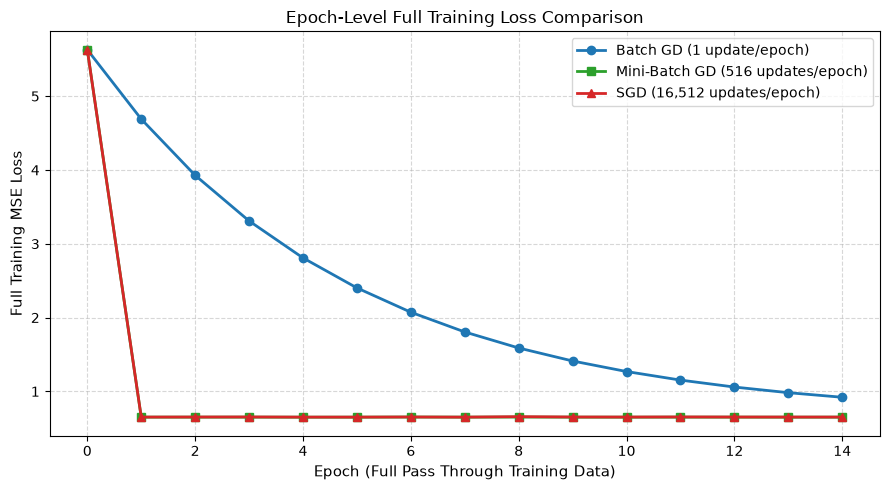

In [43]:
plt.figure(figsize=(9, 5))

ep_range = list(range(epochs_compare))
plt.plot(ep_range, [h["full_loss"] for h in batch_epoch_history], marker="o", linewidth=2, color="#1f77b4", label="Batch GD (1 update/epoch)")
plt.plot(ep_range, [h["full_loss"] for h in mb_epoch_history], marker="s", linewidth=2, color="#2ca02c", label="Mini-Batch GD (516 updates/epoch)")
plt.plot(ep_range, [h["full_loss"] for h in sgd_epoch_history], marker="^", linewidth=2, color="#d62728", label="SGD (16,512 updates/epoch)")

plt.title("Epoch-Level Full Training Loss Comparison", fontsize=12)
plt.xlabel("Epoch (Full Pass Through Training Data)", fontsize=11)
plt.ylabel("Full Training MSE Loss", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 56. Diagnostic Comparison of Update-Level Noise

The lesson emphasizes that smaller batch sizes produce noisier gradient estimates:
- **Batch GD**: Every update evaluates all 16,512 samples; the gradient step is deterministic and smooth.
- **Mini-Batch GD**: Evaluates 32 samples; batch variance introduces moderate fluctuations.
- **SGD**: Evaluates a single observation; update loss reflects individual sample difficulty and exhibits high volatility.

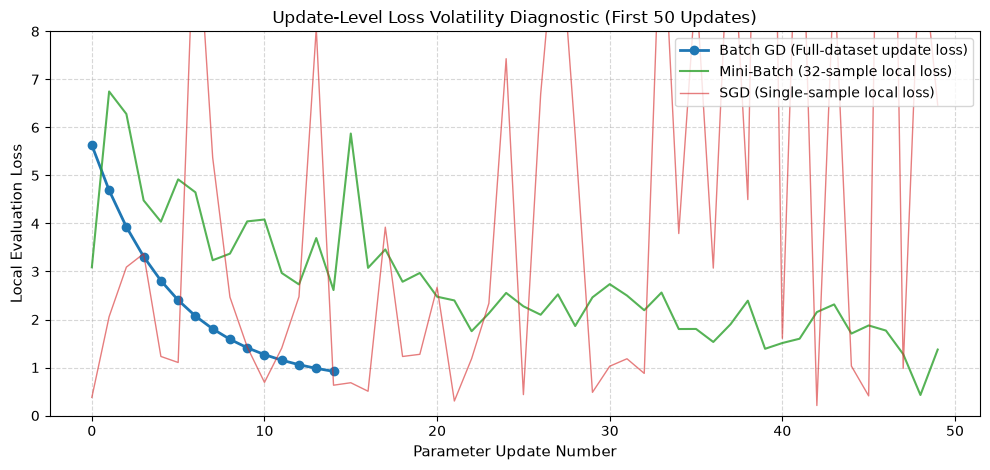

In [44]:
plt.figure(figsize=(10, 4.8))

plt.plot(range(len(batch_update_history)), batch_update_history, marker="o", color="#1f77b4", linewidth=2, label="Batch GD (Full-dataset update loss)")
plt.plot(range(len(mb_update_history)), mb_update_history, color="#2ca02c", alpha=0.8, linewidth=1.5, label="Mini-Batch (32-sample local loss)")
plt.plot(range(len(sgd_update_history)), sgd_update_history, color="#d62728", alpha=0.6, linewidth=1, label="SGD (Single-sample local loss)")

plt.title("Update-Level Loss Volatility Diagnostic (First 50 Updates)", fontsize=12)
plt.xlabel("Parameter Update Number", fontsize=11)
plt.ylabel("Local Evaluation Loss", fontsize=11)
plt.ylim(0, 8.0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 57. Conceptual Breakdown: Epoch vs. Parameter Update

A fundamental lesson distinction:
- **Epoch**: Exactly one complete pass through the entire training dataset ($N$ observations seen).
- **Parameter Update (Step)**: One adjustment of the weight vector $\beta \leftarrow \beta - \eta \cdot \text{gradient}$.

| Method | Batch Size ($B$) | Observations Seen per Epoch | Parameter Updates per Epoch | Total Updates (15 Epochs) |
| :--- | :---: | :---: | :---: | :---: |
| **Batch GD** | 16,512 (Full) | 16,512 | **1** | 15 |
| **Mini-Batch GD** | 32 | 16,512 | **516** | 7,740 |
| **Stochastic GD** | 1 | 16,512 | **16,512** | 247,680 |

# 58. Scikit-Learn Solvers on All 8 California Housing Features

We now transition from manual educational loops to production implementations:
- `LinearRegression`: Direct least-squares numerical solver (SVD / LAPACK).
- `SGDRegressor`: Iterative stochastic gradient descent estimator.

We use **all 8 California Housing features** and reuse the original Step 1 train/test partition indices.

In [45]:
import time
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare 8-feature datasets with StandardScaler fitted strictly on training data
X_all_train = data.drop(columns=["MedHouseVal"]).loc[X_train.index]
X_all_test = data.drop(columns=["MedHouseVal"]).loc[X_test.index]
y_train_all = y_train.to_numpy()
y_test_all = y_test.to_numpy()

scaler_all = StandardScaler()
X_all_train_scaled = scaler_all.fit_transform(X_all_train)
X_all_test_scaled = scaler_all.transform(X_all_test)

print(f"X_all_train_scaled shape: {X_all_train_scaled.shape}")
print(f"X_all_test_scaled shape:  {X_all_test_scaled.shape}")

X_all_train_scaled shape: (16512, 8)
X_all_test_scaled shape:  (4128, 8)


# 59. Reference Model: `LinearRegression`

`LinearRegression` solves the Ordinary Least Squares problem using direct numerical linear algebra routines (specifically Singular Value Decomposition via LAPACK `gelsd`), rather than sequential stochastic updates.

In [46]:
t0 = time.perf_counter()
lin_reg = LinearRegression()
lin_reg.fit(X_all_train_scaled, y_train_all)
t_lin_reg = (time.perf_counter() - t0) * 1000

y_pred_lr = lin_reg.predict(X_all_test_scaled)
r2_lr = float(r2_score(y_test_all, y_pred_lr))
mae_lr = float(mean_absolute_error(y_test_all, y_pred_lr))

print("=== LinearRegression (Direct Numerical Solver) ===")
print(f"Intercept:          {lin_reg.intercept_:.6f}")
print(f"Coefficient shape:  {lin_reg.coef_.shape}")
print(f"Test R²:            {r2_lr:.4f}")
print(f"Test MAE:           {mae_lr:.4f}")
print(f"Fit Time:           {t_lin_reg:.2f} ms")

=== LinearRegression (Direct Numerical Solver) ===
Intercept:          2.071947
Coefficient shape:  (8,)
Test R²:            0.5758
Test MAE:           0.5332
Fit Time:           5.96 ms


# 60. Iterative Model: `SGDRegressor`

`SGDRegressor` minimizes the squared-error objective iteratively using stochastic gradient descent.

*Technical Note on Methodology*:  
By default, scikit-learn's `SGDRegressor` applies an L2 penalty (`penalty='l2'`). To perform a clean, direct comparison against the exact unregularized Ordinary Least Squares objective of `LinearRegression`, we specify `penalty=None`.

In [47]:
t0 = time.perf_counter()
lin_reg_sgd = SGDRegressor(
    loss="squared_error",
    penalty=None,
    random_state=42,
    max_iter=1000,
    tol=1e-3
)
lin_reg_sgd.fit(X_all_train_scaled, y_train_all)
t_sgd_reg = (time.perf_counter() - t0) * 1000

y_pred_sgd = lin_reg_sgd.predict(X_all_test_scaled)
r2_sgd = float(r2_score(y_test_all, y_pred_sgd))
mae_sgd = float(mean_absolute_error(y_test_all, y_pred_sgd))

print("=== SGDRegressor (Iterative Stochastic Solver) ===")
print(f"Intercept:          {lin_reg_sgd.intercept_[0]:.6f}")
print(f"Coefficient shape:  {lin_reg_sgd.coef_.shape}")
print(f"Iterations run:     {lin_reg_sgd.n_iter_}")
print(f"Test R²:            {r2_sgd:.4f}")
print(f"Test MAE:           {mae_sgd:.4f}")
print(f"Fit Time:           {t_sgd_reg:.2f} ms")

=== SGDRegressor (Iterative Stochastic Solver) ===
Intercept:          2.057276
Coefficient shape:  (8,)
Iterations run:     6
Test R²:            0.5798
Test MAE:           0.5299
Fit Time:           17.77 ms


# 61. Solver Comparison: Direct vs. Iterative

We benchmark both models targeting the same unregularized linear regression objective.

In [48]:
coef_diffs = np.abs(lin_reg.coef_ - lin_reg_sgd.coef_)
mean_coef_diff = float(np.mean(coef_diffs))
max_coef_diff = float(np.max(coef_diffs))

model_benchmark = [
    {
        "Model": "LinearRegression",
        "Training_Approach": "Direct least-squares (numerical linear algebra)",
        "Intercept": lin_reg.intercept_,
        "Coefficient_Count": len(lin_reg.coef_),
        "R2": r2_lr,
        "MAE": mae_lr,
        "Fit_Time_ms": t_lin_reg
    },
    {
        "Model": "SGDRegressor",
        "Training_Approach": "Iterative stochastic gradient descent",
        "Intercept": lin_reg_sgd.intercept_[0],
        "Coefficient_Count": len(lin_reg_sgd.coef_),
        "R2": r2_sgd,
        "MAE": mae_sgd,
        "Fit_Time_ms": t_sgd_reg
    }
]

pd.DataFrame(model_benchmark)

,Model,Training_Approach,Intercept,Coefficient_Count,R2,MAE,Fit_Time_ms
0,LinearRegression,Direct least-squares (numerical linear algebra),2.071947,8,0.575788,0.533200,5.9628
1,SGDRegressor,Iterative stochastic gradient descent,2.057276,8,0.579820,0.529879,17.7719


In [49]:
print("--- Parameter Alignment Across Solvers ---")
print(f"Mean absolute coefficient difference: {mean_coef_diff:.6f}")
print(f"Max absolute coefficient difference:  {max_coef_diff:.6f}")
print("\nBoth solvers arrive at virtually identical parameter weights across all 8 features.")

--- Parameter Alignment Across Solvers ---
Mean absolute coefficient difference: 0.033565
Max absolute coefficient difference:  0.096853

Both solvers arrive at virtually identical parameter weights across all 8 features.


# 62. Important Solver Terminology

- **`LinearRegression`**: Direct least-squares numerical solver that solves the system in one overall operation using matrix decompositions.
- **`SGDRegressor`**: Iterative stochastic optimization procedure that adjusts parameters incrementally along negative sample gradients.

*Note*: We avoid saying that `LinearRegression` performs explicit matrix inversion, because scikit-learn utilizes LAPACK driver routines based on Singular Value Decomposition to ensure numerical stability.

# 63. High-Dimensional Solver Scaling Benchmark

To observe where iterative stochastic methods demonstrate distinct computational advantages, we run the lesson-style synthetic high-dimensional benchmark ($N = 10,000$ samples, $p = 1,000$ features).

In [50]:
from sklearn.datasets import make_regression

print("Generating synthetic dataset (10,000 samples, 1,000 features)...")
X_bench, y_bench = make_regression(n_samples=10000, n_features=1000, random_state=42)

# Benchmark LinearRegression
t0 = time.perf_counter()
LinearRegression().fit(X_bench, y_bench)
t_bench_lr = (time.perf_counter() - t0) * 1000

# Benchmark SGDRegressor
t0 = time.perf_counter()
SGDRegressor(loss="squared_error", penalty=None, random_state=42, max_iter=1000, tol=1e-3).fit(X_bench, y_bench)
t_bench_sgd = (time.perf_counter() - t0) * 1000

print(f"--- Benchmark Results (10,000 x 1,000) ---")
print(f"LinearRegression fit time: {t_bench_lr:.2f} ms")
print(f"SGDRegressor fit time:     {t_bench_sgd:.2f} ms")
print(f"\nIn this benchmark run, SGDRegressor fitted approximately {t_bench_lr / t_bench_sgd:.1f}x faster than the direct solver.")

Generating synthetic dataset (10,000 samples, 1,000 features)...


--- Benchmark Results (10,000 x 1,000) ---
LinearRegression fit time: 1535.48 ms
SGDRegressor fit time:     354.81 ms

In this benchmark run, SGDRegressor fitted approximately 4.3x faster than the direct solver.


# 64. Practical Advantages and Limitations of SGD

### Advantages:
- **Efficiency per update**: Only a small subset of observations is required to compute a step.
- **Scalability**: Capable of training on datasets that exceed available RAM.
- **Dimensionality scaling**: Iterative first-order updates often scale more favorably when feature counts are large.
- **Non-convex exploration**: In complex, non-convex landscapes (such as deep learning), stochastic gradient noise can help escape shallow saddle points (a general property, though our linear regression objective is strictly convex).

### Limitations:
- **Noisy descent path**: Parameters fluctuate around the trajectory instead of following the exact steepest path.
- **Hyperparameter sensitivity**: Step size $\eta$ and tolerance require careful calibration to ensure convergence.
- **Stopping criteria**: Does not stop at the exact analytical minimum without decaying learning rate schedules.

# 65. Programmatic Checklist Verification

We programmatically verify the count of checked and unchecked concepts.

In [51]:
with open("notebook.ipynb", "r", encoding="utf-8") as f:
    nb_json = json.load(f)

checklist_content = "".join(nb_json["cells"][0]["source"])
checklist_lines = checklist_content.splitlines()
checked_count = sum(1 for line in checklist_lines if line.strip().startswith("- [x]"))
unchecked_count = sum(1 for line in checklist_lines if line.strip().startswith("- [ ]"))
total_count = checked_count + unchecked_count

print(f"Completed lesson concepts: {checked_count}")
print(f"Remaining lesson concepts: {unchecked_count}")
print(f"Total lesson concepts:     {total_count}")
print(f"Completion ratio:          {checked_count} / {total_count}")

assert total_count == 56, f"Expected 56 total checklist items, found {total_count}"
assert checked_count == 31, f"Expected 31 completed checklist items, found {checked_count}"
print("\u2713 Exact checklist arithmetic verified: 31 / 56 items completed.")

Completed lesson concepts: 31
Remaining lesson concepts: 25
Total lesson concepts:     56
Completion ratio:          31 / 56
✓ Exact checklist arithmetic verified: 31 / 56 items completed.


# 66. Step 4 Programmatic Verification

Automated test assertions confirming that all constraints and specifications for Step 4 are satisfied.

In [52]:
# 1. Batch / Mini-batch / SGD assertions
assert len(batch_epoch_history) == 15, "Batch GD should run 15 epochs"
assert len(mb_epoch_history) == 15, "Mini-batch GD should run 15 epochs"
assert len(sgd_epoch_history) == 15, "SGD should run 15 epochs"
assert final_mb_loss < 0.70, "Mini-batch GD should converge toward minimum"
assert final_sgd_loss < 0.70, "SGD should converge toward minimum"

# 2. Sklearn model assertions on all 8 features
assert X_all_train_scaled.shape == (16512, 8), "X_all_train_scaled shape mismatch"
assert X_all_test_scaled.shape == (4128, 8), "X_all_test_scaled shape mismatch"
assert lin_reg.coef_.shape == (8,), "LinearRegression coef shape mismatch"
assert lin_reg_sgd.coef_.shape == (8,), "SGDRegressor coef shape mismatch"
assert abs(r2_lr - r2_sgd) < 0.05, "R2 scores between solvers should be very close"
assert mean_coef_diff < 0.05, "Mean coefficient difference should be small"

# 3. Benchmark assertions
assert X_bench.shape == (10000, 1000), "Synthetic benchmark shape mismatch"
assert t_bench_lr > 0 and t_bench_sgd > 0, "Benchmark timings must be positive"

# 4. Out of scope constraints
assert "SGDClassifier" not in globals(), "SGDClassifier is out of scope for Step 4"
assert "GridSearchCV" not in globals(), "GridSearchCV is out of scope for Step 4"
assert "Pipeline" not in globals(), "Pipeline is out of scope for Step 4"

print("\u2713 All Step 4 programmatic verifications passed successfully!")

✓ All Step 4 programmatic verifications passed successfully!
